# Most-Popular Baseline Model

The simplest possible recommender: rank candidate articles by how many times they were clicked in the training set.

This serves as a lower-bound benchmark â€” any smarter model should beat it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy.sparse import csr_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import normalize

TRAIN_BEHAVIORS = "../smallDataset/MINDsmall_train/behaviors.tsv"
DEV_BEHAVIORS   = "../smallDataset/MINDsmall_dev/behaviors.tsv"

COLS = ["impression_id", "user_id", "time", "history", "impressions"]

## Step 1 â€” Build popularity scores from training data

For each article, count how many times it was clicked across all training impressions.
This is the popularity score we will use to rank candidates.

In [2]:
train = pd.read_csv(TRAIN_BEHAVIORS, sep="\t", header=None, names=COLS)

click_counts = Counter()

for imp in train["impressions"]:
    for item in imp.split():
        nid, label = item.rsplit("-", 1)
        if label == "1":
            click_counts[nid] += 1

print(f"Unique articles with at least 1 click: {len(click_counts)}")
print(f"Total clicks recorded: {sum(click_counts.values())}")

Unique articles with at least 1 click: 7713
Total clicks recorded: 236344


**What this tells us:**

Out of all the articles in the training set, 7,713 were clicked at least once. 
The rest were shown to users but ignored — they get a popularity score of 0 and will always be ranked last by this model. 
This is the cold-start problem: new or unpopular articles have no signal and the model cannot help them.

## Step 2 â€” Inspect the popularity distribution

Most articles are rarely clicked; a handful are clicked very often.
This long-tail distribution is typical of news datasets.

count    7713.000000
mean       30.642292
std       136.413297
min         1.000000
25%         1.000000
50%         2.000000
75%        14.000000
max      4316.000000
dtype: float64


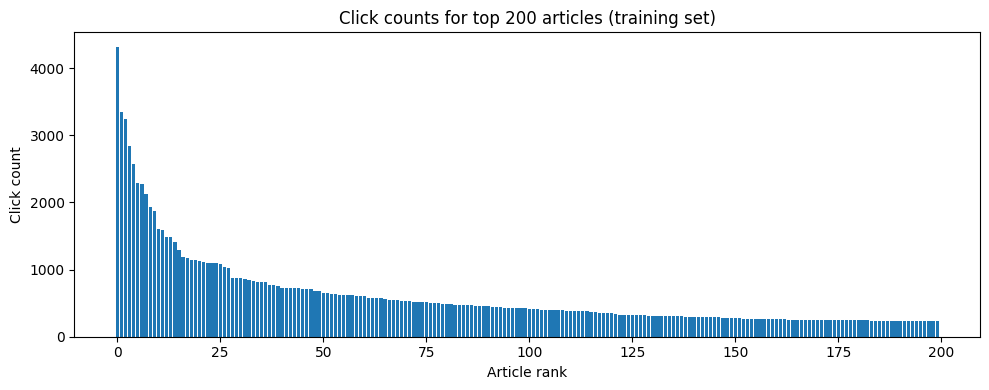


Top 185 articles (2.4%) account for 50% of all clicks


In [3]:
counts = pd.Series(click_counts).sort_values(ascending=False)

print(counts.describe())

plt.figure(figsize=(10, 4))
counts.values[:200].tolist()
plt.bar(range(200), counts.values[:200])
plt.title("Click counts for top 200 articles (training set)")
plt.xlabel("Article rank")
plt.ylabel("Click count")
plt.tight_layout()
plt.show()

# What fraction of articles account for 50% of all clicks?
total = counts.sum()
cumulative = counts.cumsum()
n_50 = (cumulative <= total * 0.5).sum()
print(f"\nTop {n_50} articles ({100*n_50/len(counts):.1f}%) account for 50% of all clicks")

**What this tells us:**

The popularity distribution is extremely skewed (mean=30, median=2). 
This means a tiny group of viral articles dominate — the top 2.4% of articles account for half of all clicks. 
The chart shows this visually: a steep drop-off after the first few articles.

For the recommender this means: the model will confidently rank a handful of mega-popular articles to the top for *every* user, 
regardless of their personal interests. That is why this is a weak baseline.

## Step 3 â€” Define the scoring function

For each impression the scorer receives a list of candidate article IDs and returns a score for each.
Articles not seen in training get a score of 0 (cold-start articles).

In [4]:
def popularity_score(history: list, candidates: list) -> list:
    """Return training click count for each candidate (0 if unseen)."""
    return [click_counts.get(nid, 0) for nid in candidates]

## Step 4 - Build inputs for Novelty and ILD

The Python recommenders compute two extra metrics besides ranking quality:

- **Novelty** uses `global_pop`, built from training-history clicks
- **ILD** uses `news_vecs`, a per-article vector space with cosine distance

This popularity baseline has no native item embeddings, so we reuse the collaborative-filtering click vectors for ILD while keeping the scorer itself purely popularity-based.

In [5]:
user_clicks = defaultdict(set)

for _, row in train.iterrows():
    uid = row["user_id"]

    if isinstance(row["history"], str) and row["history"].strip():
        for nid in row["history"].split():
            user_clicks[uid].add(nid)

    if isinstance(row["impressions"], str):
        for item in row["impressions"].split():
            nid, label = item.rsplit("-", 1)
            if label == "1":
                user_clicks[uid].add(nid)

user_to_idx = {uid: idx for idx, uid in enumerate(user_clicks)}
all_articles = sorted({nid for clicks in user_clicks.values() for nid in clicks})
article_to_idx = {nid: idx for idx, nid in enumerate(all_articles)}

rows, cols = [], []
for uid, clicks in user_clicks.items():
    u_idx = user_to_idx[uid]
    for nid in clicks:
        rows.append(u_idx)
        cols.append(article_to_idx[nid])

data = np.ones(len(rows), dtype=np.float32)
interaction = csr_matrix((data, (rows, cols)), shape=(len(user_to_idx), len(article_to_idx)))
article_user_norm = normalize(interaction.T.tocsr(), norm="l2", axis=1, copy=False)

news_vecs = {
    nid: np.asarray(article_user_norm[idx].todense()).ravel()
    for nid, idx in article_to_idx.items()
}

global_pop = defaultdict(int)
for _, row in train.iterrows():
    if isinstance(row["history"], str) and row["history"].strip():
        for nid in row["history"].split():
            global_pop[nid] += 1

print(f"ILD vectors available for {len(news_vecs)} articles")
print(f"Novelty popularity tracked for {len(global_pop)} articles")

ILD vectors available for 39865 articles
Novelty popularity tracked for 33195 articles


## Step 5 - Evaluation

We evaluate on the dev set with the same six metrics used by the Python recommender scripts:

- **AUC** - how well scores separate clicked from non-clicked articles
- **MRR** - mean reciprocal rank of the first relevant result
- **nDCG@5** - normalised discounted cumulative gain at rank 5
- **nDCG@10** - same at rank 10
- **Novelty@5 / Novelty@10** - average self-information of the top-k items
- **ILD@5 / ILD@10** - average pairwise cosine distance among the top-k items

In [6]:
def dcg_at_k(relevance, k):
    relevance = np.array(relevance[:k], dtype=np.float32)
    if relevance.size == 0:
        return 0.0
    return float((relevance / np.log2(np.arange(2, relevance.size + 2))).sum())

def ndcg_at_k(relevance, k):
    ideal = sorted(relevance, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg_at_k(relevance, k) / idcg if idcg > 0 else 0.0

def mrr(relevance):
    for i, r in enumerate(relevance):
        if r == 1:
            return 1.0 / (i + 1)
    return 0.0

def ild_at_k(top_k_ids, news_vecs, k):
    vecs = [news_vecs[nid] for nid in top_k_ids[:k] if nid in news_vecs]
    if len(vecs) < 2:
        return 0.0
    mat = np.stack(vecs)
    sim = mat @ mat.T
    m = len(vecs)
    total_sim = (sim.sum() - np.trace(sim)) / 2
    n_pairs = m * (m - 1) / 2
    return float(1.0 - total_sim / n_pairs)

def novelty_at_k(top_k_ids, global_pop, total_clicks, k):
    scores = []
    for nid in top_k_ids[:k]:
        pop = global_pop.get(nid, 1)
        scores.append(-np.log2(pop / total_clicks))
    return float(np.mean(scores)) if scores else 0.0

def evaluate(behaviors_path, score_fn, news_vecs=None, global_pop=None):
    aucs, mrrs, ndcg5s, ndcg10s = [], [], [], []
    ild5s, ild10s, nov5s, nov10s = [], [], [], []
    skipped = 0
    total_clicks = sum(global_pop.values()) if global_pop else 1

    with open(behaviors_path, encoding="utf-8") as f:
        for line in f:
            cols = line.strip().split("\t")
            if len(cols) < 5:
                continue

            history    = cols[3].strip().split() if cols[3].strip() else []
            impressions = cols[4].strip().split()

            candidates, labels = [], []
            for imp in impressions:
                parts = imp.rsplit("-", 1)
                if len(parts) != 2:
                    continue
                nid, label = parts
                candidates.append(nid)
                labels.append(int(label))

            # AUC is undefined when all labels are 0 or all are 1
            if sum(labels) == 0 or sum(labels) == len(labels):
                skipped += 1
                continue

            scores = score_fn(history, candidates)
            ranked_pairs = sorted(zip(scores, candidates, labels), reverse=True)
            ranked_labels = [lbl for _, _, lbl in ranked_pairs]
            ranked_ids = [nid for _, nid, _ in ranked_pairs]

            aucs.append(roc_auc_score(labels, scores))
            mrrs.append(mrr(ranked_labels))
            ndcg5s.append(ndcg_at_k(ranked_labels, 5))
            ndcg10s.append(ndcg_at_k(ranked_labels, 10))

            if news_vecs is not None:
                ild5s.append(ild_at_k(ranked_ids, news_vecs, 5))
                ild10s.append(ild_at_k(ranked_ids, news_vecs, 10))

            if global_pop is not None:
                nov5s.append(novelty_at_k(ranked_ids, global_pop, total_clicks, 5))
                nov10s.append(novelty_at_k(ranked_ids, global_pop, total_clicks, 10))

    print(f"Evaluated {len(aucs)} impressions | Skipped (degenerate): {skipped}")
    result = {
        "AUC":     round(float(np.mean(aucs)), 4),
        "MRR":     round(float(np.mean(mrrs)), 4),
        "nDCG@5":  round(float(np.mean(ndcg5s)), 4),
        "nDCG@10": round(float(np.mean(ndcg10s)), 4),
    }
    if ild5s:
        result["ILD@5"] = round(float(np.mean(ild5s)), 4)
        result["ILD@10"] = round(float(np.mean(ild10s)), 4)
    if nov5s:
        result["Novelty@5"] = round(float(np.mean(nov5s)), 4)
        result["Novelty@10"] = round(float(np.mean(nov10s)), 4)
    return result

In [7]:
metrics = evaluate(DEV_BEHAVIORS, popularity_score, news_vecs=news_vecs, global_pop=global_pop)

print("\nMost-Popular Baseline â€” Dev Set Results")
print("-" * 40)
for k, v in metrics.items():
    print(f"  {k:<10} {v}")

Evaluated 73152 impressions | Skipped (degenerate): 0

Most-Popular Baseline â€” Dev Set Results
----------------------------------------
  AUC        0.5318
  MRR        0.2637
  nDCG@5     0.2446
  nDCG@10    0.3063
  ILD@5      0.8398
  ILD@10     0.8882
  Novelty@5  21.6611
  Novelty@10 21.6617


**How to read the results:**

- **AUC / MRR / nDCG** tell you whether the clicked article is ranked above the non-clicked ones.
- **Novelty@k** is higher when the top-k list contains less globally popular articles.
- **ILD@k** is higher when the top-k list is more internally diverse in the click-vector space.

For this baseline, relevance metrics are expected to be modest because every user sees essentially the same ranking. Novelty is also expected to stay limited because the model intentionally prefers globally popular articles. ILD is measured in the same collaborative-filtering vector space used elsewhere in the project, since the popularity model itself has no learned item embeddings.

## Step 6 Reflect on the results

A few things to note about this baseline:

- It uses **no user information** so every user gets the same ranking.
- It completely ignores the **cold-start problem**: articles not seen in training get score 0, so they will always be ranked last regardless of actual relevance.
- It assumes **global popularity is a proxy for relevance**, which is a reasonable but weak signal.
- It should usually score worse on **Novelty** because popularity-heavy rankings concentrate on articles many users have already consumed.
- It should usually score worse on **ILD** because the top-ranked articles tend to cluster around the same broadly popular behaviour patterns.
- Any personalised model should aim to improve relevance while also lifting novelty and diversity where possible.